# Experiment 05 Analysis

This notebook reloads the trained Lightning checkpoint, recomputes held-out predictions, summarizes regression metrics, and visualizes both TensorBoard training curves and representative prediction examples.

In [1]:
import json
import os
import platform
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from omegaconf import OmegaConf
from tensorboard.backend.event_processing import event_accumulator

if platform.system() == 'Darwin':
    os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

repo_root = Path.cwd()
if not (repo_root / 'src').exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.data import ForecastDataset
from src.data.simulation import SimulationConfig, SimulationSplitConfig, generate_simulation_records
from src.utils import compose_experiment_config, load_model_from_checkpoint
from src.utils.inference import predict_arrays, regression_metrics


In [2]:
EXPERIMENT = '01'
cfg = compose_experiment_config(EXPERIMENT)
analysis_cells = int(cfg.data.val_cells)
analysis_seed = int(cfg.seed) + 47
summary = {
    'name': cfg.name,
    'seed': int(cfg.seed),
    'analysis_seed': analysis_seed,
    'analysis_cells': analysis_cells,
    'cell_class': cfg.data.cell_class,
    'solver': cfg.data.solver,
    'model': cfg.model.name,
    'past_steps': int(cfg.data.past_steps),
    'horizon': int(cfg.data.horizon),
    'sim_steps': int(cfg.data.sim_steps),
    'nostim_steps': int(cfg.data.nostim_steps),
    'batch_size': int(cfg.data.batch_size),
    'max_epochs': int(cfg.trainer.max_epochs),
}
pd.Series(summary, name='value').to_frame()


,value
name,01
seed,105
cell_class,CcaSR_gillespie_simple
solver,gillespy2
model,lstm
past_steps,36
horizon,12
sim_steps,288
nostim_steps,0
batch_size,128


In [3]:
analysis_records = generate_simulation_records(
    simulation=SimulationConfig(
        cell_class=cfg.data.cell_class,
        solver=cfg.data.solver,
        camera_noise_perc=float(cfg.data.camera_noise_perc),
        past_steps=int(cfg.data.past_steps),
        horizon=int(cfg.data.horizon),
        sim_steps=int(cfg.data.sim_steps),
        nostim_steps=int(cfg.data.nostim_steps),
    ),
    split=SimulationSplitConfig(
        name='analysis',
        num_cells=analysis_cells,
        seed=analysis_seed,
    ),
)
analysis_dataset = ForecastDataset(
    analysis_records,
    scale=float(cfg.data.scale),
    past_steps=int(cfg.data.past_steps),
    horizon=int(cfg.data.horizon),
    samples_per_cell=int(cfg.data.samples_per_cell),
    seed=analysis_seed,
    random_windows=False,
)
analysis_arrays = analysis_dataset.arrays
model = load_model_from_checkpoint(cfg)
predictions = predict_arrays(
    model,
    past=analysis_arrays['past'],
    future_stim=analysis_arrays['future_stim'],
    batch_size=int(cfg.data.batch_size),
)
metrics = regression_metrics(predictions, analysis_arrays['target'], scale=float(cfg.data.scale))
metrics['num_analysis_samples'] = int(len(analysis_arrays['target']))
metrics['checkpoint'] = str(Path(cfg.trainer.ckpt_save_fold) / 'best.ckpt')
metrics['log_dir'] = str(Path(cfg.trainer.log_save_fold))

pd.DataFrame([metrics])


Compiling GillesPy2 model for class CcaSR_gillespie_simple... done.


,rmse_mean,rmse_median,rmse_std,mae_mean,num_test_samples,checkpoint,log_dir
0,291.725739,250.433975,138.592819,253.473267,1500,/Users/tianrui.qi/Documents/GitHub/GEPC/ckpt/0...,/Users/tianrui.qi/Documents/GitHub/GEPC/log/01


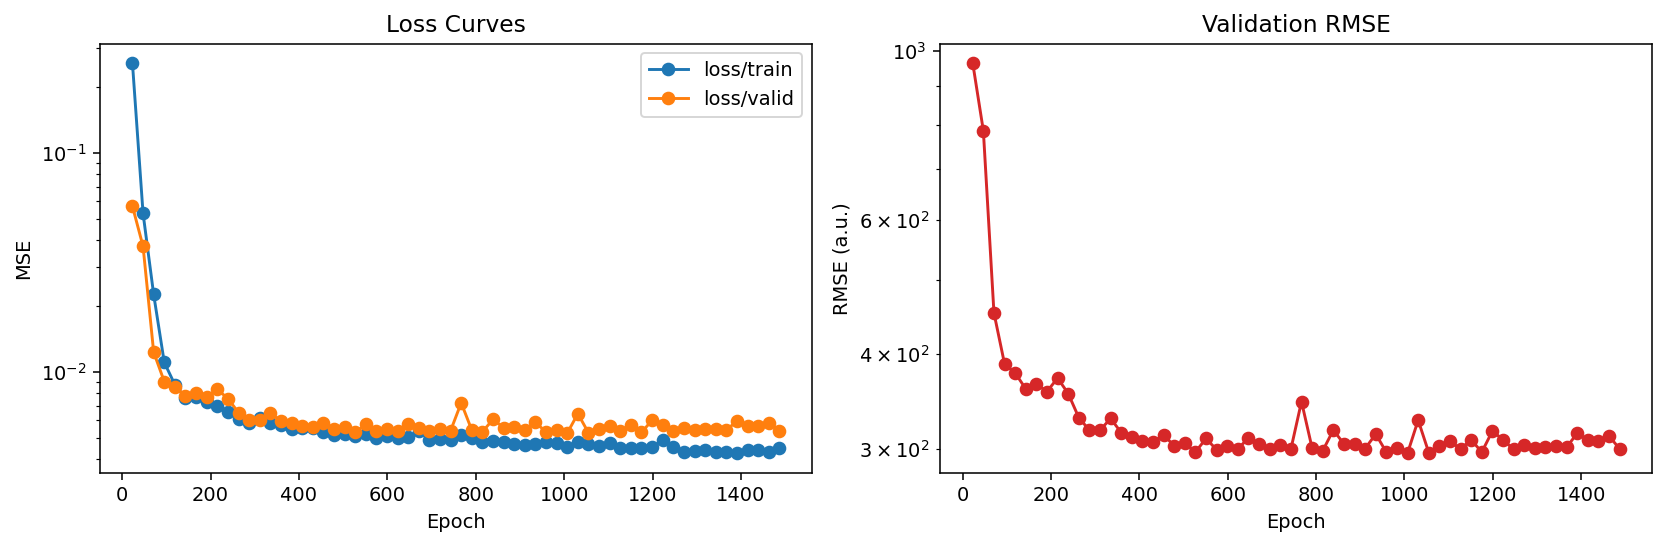

In [4]:
event_file = sorted(Path(cfg.trainer.log_save_fold).glob('events.out.tfevents.*'))[-1]
accumulator = event_accumulator.EventAccumulator(str(event_file))
accumulator.Reload()

def scalar_frame(tag: str) -> pd.DataFrame:
    events = accumulator.Scalars(tag)
    return pd.DataFrame({
        'step': [event.step for event in events],
        'value': [event.value for event in events],
        'tag': tag,
    })

curve_df = pd.concat([
    scalar_frame('loss/train'),
    scalar_frame('loss/valid'),
    scalar_frame('rmse/valid'),
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=140)
loss_df = curve_df[curve_df['tag'].isin(['loss/train', 'loss/valid'])]
for tag, frame in loss_df.groupby('tag'):
    axes[0].plot(frame['step'], frame['value'], marker='o', label=tag)
axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].set_yscale('log')
axes[0].legend()

rmse_df = curve_df[curve_df['tag'] == 'rmse/valid']
axes[1].plot(rmse_df['step'], rmse_df['value'], marker='o', color='#d62728')
axes[1].set_title('Validation RMSE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('RMSE (a.u.)')
axes[1].set_yscale('log')
plt.tight_layout()
plt.show()

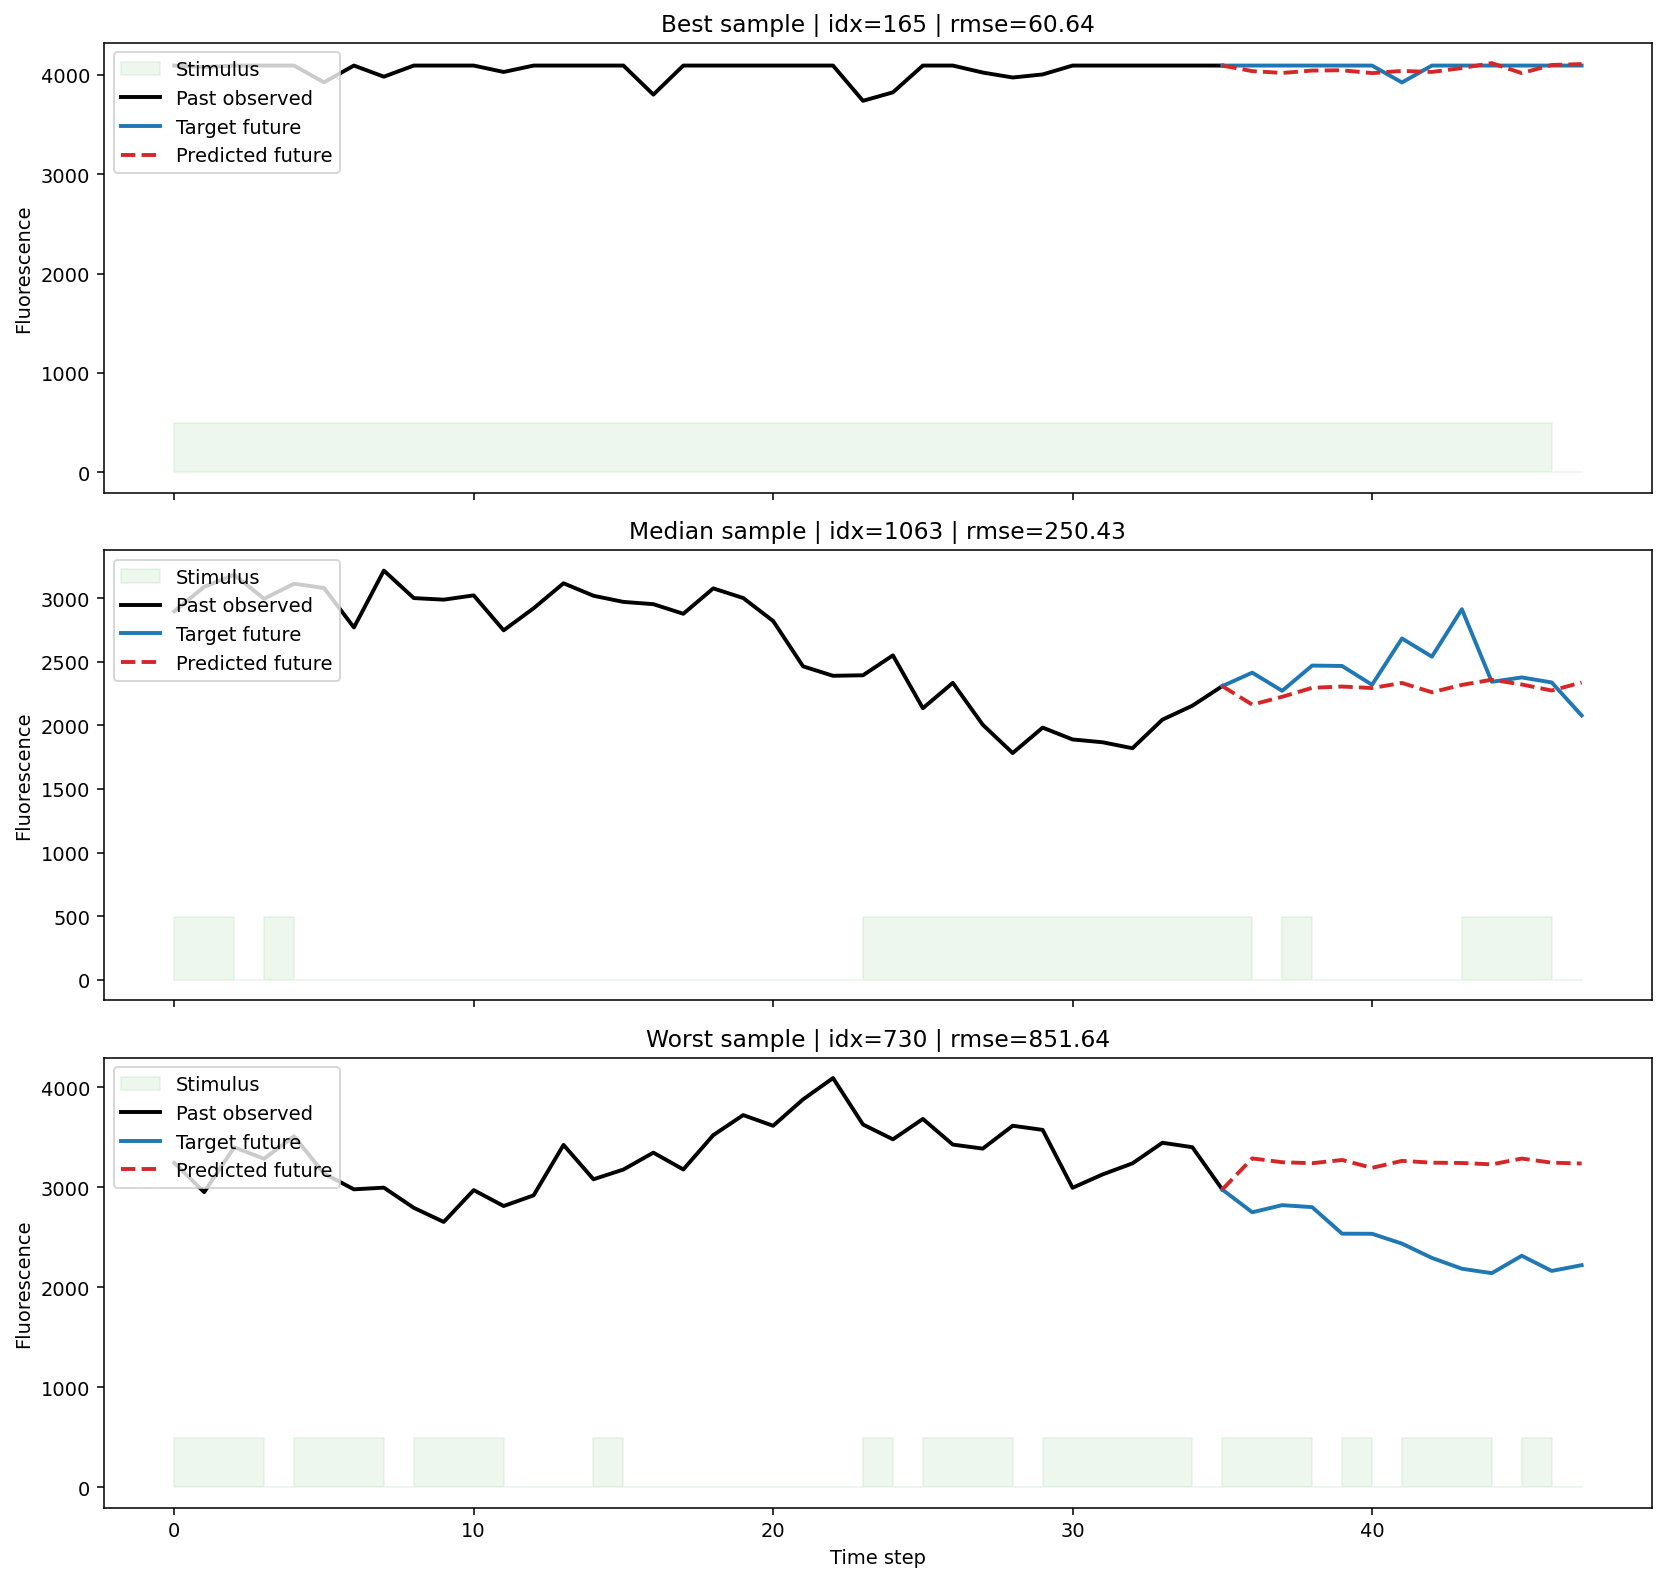

In [5]:
scale = float(cfg.data.scale)
targets = analysis_arrays['target']
observed = analysis_arrays['observed']
stimulus = analysis_arrays['stimulus']
rmse_per_sample = np.sqrt(np.mean(((predictions - targets) * scale) ** 2, axis=1))
ranked = np.argsort(rmse_per_sample)
example_indices = [int(ranked[0]), int(ranked[len(ranked) // 2]), int(ranked[-1])]
example_labels = ['Best', 'Median', 'Worst']

fig, axes = plt.subplots(len(example_indices), 1, figsize=(12, 3.8 * len(example_indices)), dpi=140, sharex=True)
axes = np.atleast_1d(axes)
past_steps = int(cfg.data.past_steps)
future_axis = np.arange(past_steps - 1, past_steps + int(cfg.data.horizon))
full_axis = np.arange(past_steps + int(cfg.data.horizon))

for axis, label, idx in zip(axes, example_labels, example_indices):
    full_observed = observed[idx]
    future_target = targets[idx] * scale
    future_prediction = predictions[idx] * scale
    axis.fill_between(full_axis, 0, stimulus[idx] * scale * 0.12, step='pre', alpha=0.08, color='#2ca02c', label='Stimulus')
    axis.plot(np.arange(past_steps), full_observed[:past_steps], color='black', linewidth=2, label='Past observed')
    axis.plot(future_axis, np.concatenate([[full_observed[past_steps - 1]], future_target]), color='#1f77b4', linewidth=2, label='Target future')
    axis.plot(future_axis, np.concatenate([[full_observed[past_steps - 1]], future_prediction]), color='#d62728', linewidth=2, linestyle='--', label='Predicted future')
    axis.set_title(f'{label} sample | idx={idx} | rmse={rmse_per_sample[idx]:.2f}')
    axis.set_ylabel('Fluorescence')
    axis.legend(loc='upper left')

axes[-1].set_xlabel('Time step')
plt.tight_layout()
plt.show()


In [6]:
OmegaConf.to_container(cfg, resolve=True)

{'data': {'cell_class': 'CcaSR_gillespie_simple',
  'solver': 'gillespy2',
  'camera_noise_perc': 5.0,
  'scale': 4095.0,
  'past_steps': 36,
  'horizon': 12,
  'sim_steps': 288,
  'nostim_steps': 0,
  'batch_size': 128,
  'num_workers': 0,
  'shuffle': True,
  'train_cells': 10,
  'val_cells': 5,
  'test_cells': 5,
  'samples_per_cell': 300,
  'seed': 105},
 'model': {'name': 'lstm',
  'input_dim': 2,
  'horizon': 12,
  'encoder_hidden_size': 64,
  'latent_dim': 32,
  'future_hidden_size': 64,
  'decoder_hidden_sizes': [128, 64],
  'dropout': 0.0},
 'objective': {'lr': 0.001,
  'weight_decay': 0.0,
  'step_size': 10,
  'gamma': 0.95,
  'scale': 4095.0},
 'trainer': {'max_epochs': 200,
  'patience': 20,
  'accelerator': 'auto',
  'devices': 1,
  'precision': 32,
  'deterministic': True,
  'gradient_clip_val': 1.0,
  'log_every_n_steps': 1,
  'limit_train_batches': 1.0,
  'limit_val_batches': 1.0,
  'log_save_fold': '/Users/tianrui.qi/Documents/GitHub/GEPC/log/01',
  'ckpt_save_fold': '